<a href="https://colab.research.google.com/github/Fredy-Patricio/1.2.1_1Pandas/blob/main/Practica1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Uso de aplicación colaborativa **GOOGLE COLAB** #

#Análisis del **Precio de ventas de Inmuebles** en Ecuador 🇪🇨#

##INSTALAR LIBRERIAS A UTILIZAR##
#Pandas,NumPy, Scikit-learn, TensorFlow, matplotlib, bokeh#

In [ ]:
!pip install pandas numpy scikit-learn matplotlib bokeh

## Descargar el archivo CSV https://zenodo.org/record/6423286 ## real_state_ecuador_dataset.csv

Cargar el archivo CSV con pandas

In [ ]:
# Importamos pandas
import pandas as pd

# Cargar el archivo CSV en un DataFrame
df = pd.read_csv('/content/real_state_ecuador_dataset.csv')

# Mostrar las primeras 5 filas del archivo
df.head()

,Titulo,Precio,Provincia,Lugar,Num. dormitorios,Num. banos,Area,Num. garages
0,Hermoso departamento de arriendo sector iñaquito,500,Pichincha,"Pichincha, Iñaquito, Quito, Ecuador",2,2,95,1
1,Hermosa suite de arriendo sector iñaquito,375,Pichincha,"Pichincha, Quito, Ecuador",1,1,65,1
2,Hermoso departamento de oportunidad de arriend...,650,Pichincha,"Pichincha, Av. República de El Salvador, Quito...",2,2,120,1
3,Hermoso departamento de arriendo de 240 metros...,560,Pichincha,"Pichincha, Albert Einstein, Quito, Ecuador",3,3,240,2
4,Hermoso departamento de arriendo de oportunida...,580,Pichincha,"Pichincha, Urbanización El Condado, Calle C, Q...",3,4,128,2


In [ ]:
# Ver las columnas, tipos de datos y si hay valores nulos
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1084 entries, 0 to 1083
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Titulo            1084 non-null   object
 1   Precio            1084 non-null   object
 2   Provincia         1084 non-null   object
 3   Lugar             1084 non-null   object
 4   Num. dormitorios  802 non-null    object
 5   Num. banos        824 non-null    object
 6   Area              1000 non-null   object
 7   Num. garages      670 non-null    object
dtypes: object(8)
memory usage: 67.9+ KB


##Agregar **cuatro columnas al dataframe**, en función de los datos originales.##

  # Eliminar filas que tengan valores nulos (NaN)

In [ ]:
df = df.dropna() # elimino filas con los valores nulos

In [ ]:
print("Número de filas después de eliminar datos nulos:", len(df)) #imprimir las filas luego de el nulos

Número de filas después de eliminar datos nulos: 619


In [ ]:
print (df) #imprimo el df luego de eliminar filas nulas

                                                 Titulo  Precio  Provincia  \
0      Hermoso departamento de arriendo sector iñaquito     500  Pichincha   
1             Hermosa suite de arriendo sector iñaquito     375  Pichincha   
2     Hermoso departamento de oportunidad de arriend...     650  Pichincha   
3     Hermoso departamento de arriendo de 240 metros...     560  Pichincha   
4     Hermoso departamento de arriendo de oportunida...     580  Pichincha   
...                                                 ...     ...        ...   
1074     SE VENDE DEPARTAMENTO EN “EL INCA” EN CONJUNTO   69000  Pichincha   
1075  CASA EN VENTA POR ESTRENAR TUMBACO CONJUNTO PR...  220000  Pichincha   
1077      VENDO BONITO DEPARTAMENTO ,SECTOR LAS CUADRAS   36000  Pichincha   
1081               DEPARTAMENTO EN RENTA SECTOR KENNEDY     415  Pichincha   
1083                          CASA DE VENTA EN PONCIANO  250000  Pichincha   

                                                  Lugar Num. do

In [ ]:
print(df.columns)

Index(['Titulo', 'Precio', 'Provincia', 'Lugar', 'Num. dormitorios',
       'Num. banos', 'Area', 'Num. garages'],
      dtype='object')


## Agregar 4 columnas ##

In [ ]:
# Primero revisamos las columnas que vamos a convertir str,float
columnas_a_convertir = ['Precio', 'Area', 'Num. dormitorios', 'Num. banos']

for col in columnas_a_convertir:# Limpiamos y convertimos cada columna
    df[col] = df[col].astype(str)  # asegurarse que son string primero
    df[col] = df[col].str.replace(',', '')  # quitar comas
    df[col] = df[col].str.replace('$', '')  # quitar signos de dólar si hay
    df[col] = df[col].str.strip()  # quitar espacios
    df[col] = pd.to_numeric(df[col], errors='coerce')  # convertir a número, pone NaN si no puede

# Eliminar filas con datos no convertibles
df = df.dropna(subset=columnas_a_convertir)

# Verificamos los tipos de datos
df[columnas_a_convertir].dtypes

,0
Precio,float64
Area,float64
Num. dormitorios,float64
Num. banos,float64


Realizamos el calculo para luego añadir en la tabla

In [ ]:
# 1. Calculo de Precio por metro cuadrado
df['precio_por_m2'] = df['Precio'] / df['Area']

# 2. Relación habitaciones por baño
df['habitaciones_por_bano'] = df['Num. dormitorios'] / df['Num. dormitorios']

# 3. Clasificación del tamaño del inmueble
df['tamanio_categoria'] = pd.cut(df['Area'], bins=[0, 50, 100, 200, 1000],
                                  labels=['Pequeño', 'Mediano', 'Grande', 'Muy Grande'])

# 4. Precio en miles (para visualizaciones más limpias)
df['precio_miles'] = df['Precio'] / 1000

# Mostrar las nuevas columnas
df[['precio_por_m2', 'habitaciones_por_bano', 'tamanio_categoria', 'precio_miles']].head()

,precio_por_m2,habitaciones_por_bano,tamanio_categoria,precio_miles
0,5.263158,1.0,Mediano,0.500
1,5.769231,1.0,Mediano,0.375
2,5.416667,1.0,Grande,0.650
3,2.333333,1.0,Muy Grande,0.560
4,4.531250,1.0,Grande,0.580


In [ ]:
print(df.columns) #imprimo todo mas las columnas adicionadas

Index(['Titulo', 'Precio', 'Provincia', 'Lugar', 'Num. dormitorios',
       'Num. banos', 'Area', 'Num. garages', 'precio_por_m2',
       'habitaciones_por_bano', 'tamanio_categoria', 'precio_miles'],
      dtype='object')


##Visualización de datos##

Gráfico de dispersión con Matplotlib

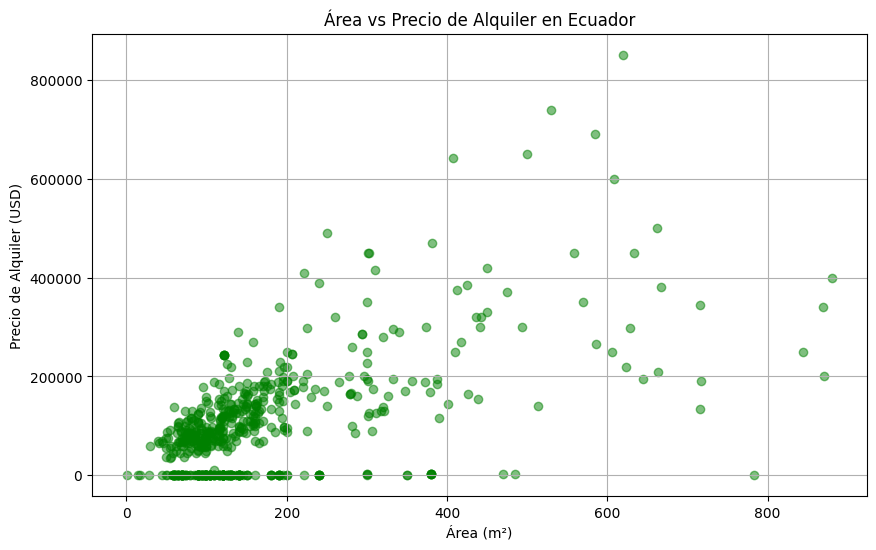

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(df['Area'], df['Precio'], alpha=0.5, c='green')
plt.title('Área vs Precio de Alquiler en Ecuador')
plt.xlabel('Área (m²)')
plt.ylabel('Precio de Alquiler (USD)')
plt.grid(True)
plt.show()

Gráfico interactivo con Bokeh

In [ ]:
# Filtrar las columnas y limpiar los datos
df_filtrado = df[['Precio', 'Area', 'Provincia']].dropna()
df_filtrado['Provincia'] = df_filtrado['Provincia'].astype(str).apply(quitar_acentos)
df_filtrado['Area'] = pd.to_numeric(df_filtrado['Area'], errors='coerce')
df_filtrado['Precio'] = pd.to_numeric(df_filtrado['Precio'], errors='coerce')
df_filtrado = df_filtrado.dropna()  # Eliminar cualquier fila con valores nulos

print(df_filtrado[['Area', 'Precio', 'Provincia']].head())

    Area  Precio  Provincia
0   95.0   500.0  Pichincha
1   65.0   375.0  Pichincha
2  120.0   650.0  Pichincha
3  240.0   560.0  Pichincha
4  128.0   580.0  Pichincha


In [ ]:
df['Precio']

,Precio
0,500.0
1,375.0
2,650.0
3,560.0
4,580.0
...,...
1074,69000.0
1075,220000.0
1077,36000.0
1081,415.0


In [ ]:
from bokeh.plotting import figure, show, output_notebook
from bokeh.models import ColumnDataSource, HoverTool

output_notebook()

source = ColumnDataSource(df_filtrado)

p = figure(title="Area vs Precio (Gráfico Interactivo)",
           x_axis_label='Area (m²)', y_axis_label='precio_miles (USD)',
           width=700, height=400)

p.scatter(x='Area', y='Precio', size=8, source=source, color="navy", alpha=0.5)

hover = HoverTool(tooltips=[
    ("Area", "@Area m²"),
    ("Precio", "@Precio USD"),
    ("Provincia", "@Provincia")
])
p.add_tools(hover)

show(p)